# Analyse HSIC-ANOVA hiérarchique sur sorties MAELIA réelles

Ce notebook applique la méthode HSIC-ANOVA hiérarchique aux sorties réellement produites par MAELIA.

La logique est la suivante :

- normalisation des variables continues ;
- **imputation marginale aléatoire** des valeurs inactives (sentinelle) avant l'apprentissage, pour que les variables structurelles (`n_ferti`, `nb_prepa`) ne soient pas rendues artificiellement redondantes par les sentinelles de dose/date — même traitement que la webapp `maelia_sa_pipeline` ;
- apprentissage d'une Random Forest par sortie ;
- importance par permutation conditionnelle pour construire les échelles de noyaux `theta` ;
- appel à `hsic_anova_hierarchical` avec les variables actives/inactives du plan hiérarchique.

Note pratique : HSIC construit des matrices de distance en `n × n`. Pour éviter une explosion mémoire sur les 5000 simulations, le notebook contient un paramètre `HSIC_MAX_SAMPLES`.

## 1. Imports, chemins et paramètres

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'maelia_sa_pipeline').exists():
            return candidate
    raise RuntimeError('Racine du dépôt introuvable depuis le répertoire courant.')

PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / 'analysis'
TOOLS_DIR = ANALYSIS_DIR / 'tools'
OUTPUT_DIR = ANALYSIS_DIR / 'hsic_anova_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

from hsic_methods import hsic_anova_hierarchical

OUTPUT_COLS = ['N_lixi', 'dCorg', 'rdt']
DATASET_FILENAME = 'dataset_metamodel.csv'
DATASET_CANDIDATES = [
    PROJECT_ROOT / 'simulations' / 'log_terrainSA',
    ANALYSIS_DIR / DATASET_FILENAME,
]

RANDOM_SEED = 43
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = 10
RF_MIN_SAMPLES_LEAF = 15
PERMUTATION_REPEATS = 10
THETA_SCALE = 5.0
THETA_IMPORTANCE_THRESHOLD = 0.005
HSIC_MAX_ORDER = 4

# Mettre None pour utiliser tous les points. Attention : coût mémoire en O(n² × p).
HSIC_MAX_SAMPLES = 5000

print(f'Projet : {PROJECT_ROOT}')
print(f'Outils HSIC : {TOOLS_DIR}')
print(f'Sorties : {OUTPUT_DIR}')


Projet : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA
Outils HSIC : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/tools
Sorties : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results


## 2. Chargement du dataset réel MAELIA

In [2]:
def resolve_dataset_path(candidates, filename=DATASET_FILENAME):
    checked = []
    for candidate in candidates:
        candidate = Path(candidate).expanduser()
        checked.append(candidate)

        if candidate.is_file():
            return candidate, checked

        if candidate.is_dir():
            direct_csv = candidate / filename
            checked.append(direct_csv)
            if direct_csv.is_file():
                return direct_csv, checked

            nested = sorted(candidate.rglob(filename))
            checked.extend(nested[:5])
            if nested:
                return nested[0], checked

    return None, checked


DATASET_PATH, checked_dataset_paths = resolve_dataset_path(DATASET_CANDIDATES)

if DATASET_PATH is None:
    print('Aucun dataset terrainSA trouvé. Chemins testés :')
    for candidate in checked_dataset_paths:
        print(' -', candidate)
    raise FileNotFoundError(
        'Exécuter le notebook de simulation terrainSA jusqu’à export de dataset_metamodel.csv, '
        'ou renseigner DATASET_CANDIDATES avec le dossier contenant ce fichier.'
    )

df_raw = pd.read_csv(DATASET_PATH)
print('Dataset chargé :', DATASET_PATH)
print('Dimensions :', df_raw.shape)
display(df_raw.head())

EXPECTED_N_FEATURES = 14
feat_cols = [f'feat_{i}' for i in range(EXPECTED_N_FEATURES)]
missing_features = [col for col in feat_cols if col not in df_raw.columns]
missing_outputs = [col for col in OUTPUT_COLS if col not in df_raw.columns]

if missing_features:
    raise ValueError(
        'Le dataset doit contenir les colonnes feat_* du plan SMT courant. '
        f'Colonnes manquantes : {missing_features}'
    )
if missing_outputs:
    raise ValueError(f'Sorties MAELIA absentes du dataset : {missing_outputs}')


Dataset chargé : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/simulations/log_terrainSA/dataset_metamodel.csv
Dimensions : (5000, 21)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_11,feat_12,feat_13,Milieu (Climat),Milieu (Sol),N_lixi,dCorg,rdt,point_idx,parcelle
0,1,1,47.0,-12.0,3.6,3.7,-1.0,190.0,-1.0,-1.0,...,50.6,-1.0,-1.0,0,0,1.708947,-130.155789,7.906667,0,beauce_5_sa_000
1,0,0,90.0,-1.0,1.1,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,0,0,1.942105,-150.847895,5.337778,1,beauce_5_sa_001
2,2,2,86.0,-9.0,1.6,14.0,3.9,218.0,294.0,-1.0,...,20.7,76.6,-1.0,0,0,4.952105,-57.965263,8.462222,2,beauce_5_sa_002
3,3,0,51.0,-1.0,3.1,-1.0,-1.0,179.0,272.0,321.0,...,4.6,5.2,99.5,0,0,9.763158,-94.182105,8.344444,3,beauce_5_sa_003
4,3,2,102.0,-43.0,1.3,9.3,21.6,130.0,265.0,317.0,...,79.0,35.1,9.7,0,0,5.100526,-2.077368,8.988889,4,beauce_5_sa_004


## 3. Reconstruction des 14 paramètres agricoles

In [3]:
AGRI_FEATURES = [
    'n_ferti', 'nb_prepa',
    'Date_Semis', 'Delta_PREPA_Semis', 'Profondeur_Semis',
    'Profondeur_Prepa_1', 'Profondeur_Prepa_2',
    'Date_F1', 'Date_F2', 'Date_F3', 'Date_Recolte',
    'Dose_F1', 'Dose_F2', 'Dose_F3',
]

# Canonical English names used in figures and scientific communication.
# Raw names are kept above to remain compatible with existing terrainSA datasets.
FEATURE_DISPLAY_NAMES = {
        'n_ferti': 'Number_Of_Fertilisations',
    'nb_prepa': 'Number_Of_Preparations',
    'Profondeur_Prepa_1': 'First_Tillage_Depth',
    'Profondeur_Prepa_2': 'Second_Tillage_Depth',
    'Delta_PREPA_Semis': 'Preparation_To_Sowing_Delay',
    'Date_Semis': 'Sowing_Date',
    'Profondeur_Semis': 'Sowing_Depth',
    'Date_Recolte': 'Harvest_Date',
    'Date_F1': 'First_Fertilisation_Date',
    'Dose_F1': 'First_Fertilisation_Dose',
    'Date_F2': 'Second_Fertilisation_Date',
    'Dose_F2': 'Second_Fertilisation_Dose',
    'Date_F3': 'Third_Fertilisation_Date',
    'Dose_F3': 'Third_Fertilisation_Dose',
}

OUTPUT_DISPLAY_NAMES = {
    'N_lixi': 'Nitrogen leaching',
    'dCorg': 'Soil organic carbon change',
    'rdt': 'Yield',
}

AGRI_CATEGORICAL = ['n_ferti', 'nb_prepa']
AGRI_CONTINUOUS = [feature for feature in AGRI_FEATURES if feature not in AGRI_CATEGORICAL]

feat_cols = [f'feat_{i}' for i in range(len(AGRI_FEATURES))]
X_params = df_raw[feat_cols].copy()
X_params.columns = AGRI_FEATURES
for col in AGRI_FEATURES:
    X_params[col] = pd.to_numeric(X_params[col], errors='coerce')

Y_outputs = df_raw[OUTPUT_COLS].copy()
for col in OUTPUT_COLS:
    Y_outputs[col] = pd.to_numeric(Y_outputs[col], errors='coerce')

df = pd.concat([X_params, Y_outputs], axis=1).dropna(subset=OUTPUT_COLS).reset_index(drop=True)
print('Number of usable rows:', len(df))
print('Agricultural parameters:', len(AGRI_FEATURES))
print('Outputs:', [OUTPUT_DISPLAY_NAMES.get(name, name) for name in OUTPUT_COLS])
display(df[AGRI_FEATURES + OUTPUT_COLS].head())


Number of usable rows: 5000
Agricultural parameters: 14
Outputs: ['Nitrogen leaching', 'Soil organic carbon change', 'Yield']


,n_ferti,nb_prepa,Date_Semis,Delta_PREPA_Semis,Profondeur_Semis,Profondeur_Prepa_1,Profondeur_Prepa_2,Date_F1,Date_F2,Date_F3,Date_Recolte,Dose_F1,Dose_F2,Dose_F3,N_lixi,dCorg,rdt
0,1,1,47.0,-12.0,3.6,3.7,-1.0,190.0,-1.0,-1.0,368.0,50.6,-1.0,-1.0,1.708947,-130.155789,7.906667
1,0,0,90.0,-1.0,1.1,-1.0,-1.0,-1.0,-1.0,-1.0,374.0,-1.0,-1.0,-1.0,1.942105,-150.847895,5.337778
2,2,2,86.0,-9.0,1.6,14.0,3.9,218.0,294.0,-1.0,380.0,20.7,76.6,-1.0,4.952105,-57.965263,8.462222
3,3,0,51.0,-1.0,3.1,-1.0,-1.0,179.0,272.0,321.0,374.0,4.6,5.2,99.5,9.763158,-94.182105,8.344444
4,3,2,102.0,-43.0,1.3,9.3,21.6,130.0,265.0,317.0,348.0,79.0,35.1,9.7,5.100526,-2.077368,8.988889


## 4. Variables actives/inactives du plan hiérarchique

La méthode HSIC doit savoir si une variable est active pour chaque simulation. Ici, cette information est reconstruite depuis la logique du plan SMT réellement utilisé : par exemple `Date_F2` et `Dose_F2` ne sont actives que si `n_ferti >= 2`, et `Profondeur_Prepa_2` n'est active que lorsqu'une préparation du sol avec deux opérations est décrétée.

In [4]:
FEATURE_INDEX = {name: i for i, name in enumerate(AGRI_FEATURES)}

CONDITIONALLY_ACTING = ['nb_prepa', 'Delta_PREPA_Semis', 'Profondeur_Prepa_1', 'Profondeur_Prepa_2', 'Date_F1', 'Dose_F1', 'Date_F2', 'Dose_F2', 'Date_F3', 'Dose_F3']

num_is_decreed = np.array([feature in CONDITIONALLY_ACTING for feature in AGRI_FEATURES], dtype=bool)
is_categorical = np.array([feature in AGRI_CATEGORICAL for feature in AGRI_FEATURES], dtype=bool)


def build_acting_matrix(X_df):
    acting = np.ones((len(X_df), len(AGRI_FEATURES)), dtype=bool)

    n_ferti = X_df['n_ferti'].to_numpy()
    nb_prepa = X_df['nb_prepa'].to_numpy()

    def set_active(feature, mask):
        acting[:, FEATURE_INDEX[feature]] = mask

    for feature in ['Delta_PREPA_Semis', 'Profondeur_Prepa_1']:
        set_active(feature, nb_prepa >= 1)
    set_active('Profondeur_Prepa_2', nb_prepa >= 2)

    for feature in ['Date_F1', 'Dose_F1']:
        set_active(feature, n_ferti >= 1)
    for feature in ['Date_F2', 'Dose_F2']:
        set_active(feature, n_ferti >= 2)
    for feature in ['Date_F3', 'Dose_F3']:
        set_active(feature, n_ferti >= 3)

    return acting


x_is_acting_full = build_acting_matrix(df[AGRI_FEATURES])
acting_summary = pd.DataFrame({
    'variable': AGRI_FEATURES,
    'conditionnelle': num_is_decreed,
    'categorielle': is_categorical,
    'frequence_active': x_is_acting_full.mean(axis=0),
})
display(acting_summary)
acting_summary.to_csv(OUTPUT_DIR / 'hsic_variable_acting_summary.csv', index=False)


,variable,conditionnelle,categorielle,frequence_active
0,n_ferti,False,True,1.0000
1,nb_prepa,True,True,1.0000
2,Date_Semis,False,False,1.0000
3,Delta_PREPA_Semis,True,False,0.6578
4,Profondeur_Semis,False,False,1.0000
5,Profondeur_Prepa_1,True,False,0.6578
6,Profondeur_Prepa_2,True,False,0.3270
7,Date_F1,True,False,0.7518
8,Date_F2,True,False,0.5000
9,Date_F3,True,False,0.2460


## 5. Normalisation numérique

Les variables continues sont ramenées dans `[0, 1]` sur les bornes observées dans le dataset réel. Les variables catégorielles restent sous leur codage entier, car `hsic_methods.py` leur applique une distance d'égalité/différence.

In [5]:
X_numeric_full = df[AGRI_FEATURES].copy()

for col in AGRI_FEATURES:
    X_numeric_full[col] = pd.to_numeric(X_numeric_full[col], errors='coerce')

for col in AGRI_CATEGORICAL:
    X_numeric_full[col] = X_numeric_full[col].fillna(0).round().astype(float)

# Pour les catégorielles conditionnelles, on force une modalité inactive dédiée.
# Sinon une variable inactive codée 0 pourrait être confondue avec une vraie modalité active 0.
for col in AGRI_CATEGORICAL:
    idx = FEATURE_INDEX[col]
    if num_is_decreed[idx]:
        X_numeric_full.loc[~x_is_acting_full[:, idx], col] = -1.0

for col in AGRI_CONTINUOUS:
    values = X_numeric_full[col].astype(float)
    fill_value = values.median()
    values = values.fillna(fill_value)
    vmin = values.min()
    vmax = values.max()
    if np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin:
        X_numeric_full[col] = (values - vmin) / (vmax - vmin)
    else:
        X_numeric_full[col] = 0.0

X_numeric_full = X_numeric_full.to_numpy(dtype=float)
print('Matrice X normalisée :', X_numeric_full.shape)


Matrice X normalisée : (5000, 14)


## 6. Sous-échantillon HSIC reproductible

La Random Forest est entraînée sur toutes les lignes disponibles. Le calcul HSIC peut ensuite être réalisé sur un sous-échantillon reproductible pour rester compatible avec la mémoire disponible.

In [6]:
rng = np.random.default_rng(RANDOM_SEED)
n_total = len(df)

if HSIC_MAX_SAMPLES is None or HSIC_MAX_SAMPLES >= n_total:
    hsic_idx = np.arange(n_total)
else:
    hsic_idx = np.sort(rng.choice(n_total, size=HSIC_MAX_SAMPLES, replace=False))

X_hsic = X_numeric_full[hsic_idx]
x_is_acting_hsic = x_is_acting_full[hsic_idx]

print(f'Points disponibles : {n_total}')
print(f'Points utilisés pour HSIC : {len(hsic_idx)}')
pd.Series(hsic_idx, name='row_index').to_csv(OUTPUT_DIR / 'hsic_sample_indices.csv', index=False)


Points disponibles : 5000
Points utilisés pour HSIC : 5000


## 7. Random Forest supervisée et HSIC-ANOVA par sortie

In [7]:
all_importance_tables = []
all_hsic_tables = []
summary_rows = []

for output in OUTPUT_COLS:
    print()
    print('=' * 90)
    print(f'Sortie MAELIA : {output}')
    print('=' * 90)

    y_full = df[output].to_numpy(dtype=float)
    y_hsic = y_full[hsic_idx]

    rf = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    # Imputation marginale aleatoire (alignee sur la webapp maelia_sa_pipeline/hsic.py).
    # Les valeurs INACTIVES (sentinelle) de chaque colonne sont remplacees par des
    # valeurs tirees au hasard parmi les lignes ACTIVES de la meme colonne, AVANT
    # d'ajuster la RF. Sans cela, une dose inactive (normalisee a 0) trahit
    # n_ferti/nb_prepa : la RF deduit la structure des sentinelles, les variables
    # structurelles deviennent redondantes (importance ~ 0, theta = 0) et disparaissent
    # a tort du HSIC. L'imputation casse ce raccourci et restitue leur vraie importance.
    # La RF est entrainee sur la matrice imputee ; l'importance par permutation
    # conditionnelle reste evaluee sur la matrice brute X_numeric_full.
    rng_impute = np.random.default_rng(RANDOM_SEED)
    X_rf_full = X_numeric_full.copy()
    for i in range(X_numeric_full.shape[1]):
        inactive_idx = np.where(~x_is_acting_full[:, i])[0]
        active_idx = np.where(x_is_acting_full[:, i])[0]
        if len(inactive_idx) > 0 and len(active_idx) > 0:
            X_rf_full[inactive_idx, i] = rng_impute.choice(
                X_numeric_full[active_idx, i], size=len(inactive_idx)
            )
    rf.fit(X_rf_full, y_full)

    # Importance par permutation CONDITIONNELLE : chaque variable n'est permutee
    # que parmi les lignes ou elle est active (respect de la hierarchie SMT), la
    # hausse de MSE etant normalisee par la variance du sous-ensemble actif. Aligne
    # le notebook sur la methode de la webapp, au lieu de la permutation globale de
    # sklearn qui melange lignes actives et inactives (valeurs par defaut) des
    # variables conditionnelles.
    n_features = X_numeric_full.shape[1]
    imp_mean = np.zeros(n_features)
    imp_std = np.zeros(n_features)
    rng_cpi = np.random.RandomState(RANDOM_SEED)
    for i in range(n_features):
        active_idx = np.where(x_is_acting_full[:, i])[0]
        if len(active_idx) < 2:
            continue
        pred_base = rf.predict(X_numeric_full[active_idx])
        mse_base = np.mean((y_full[active_idx] - pred_base) ** 2)
        var_active = np.var(y_full[active_idx])
        if var_active <= 1e-6:
            continue
        reps = []
        for _ in range(PERMUTATION_REPEATS):
            x_shuff = X_numeric_full.copy()
            shuffled_vals = x_shuff[active_idx, i].copy()
            rng_cpi.shuffle(shuffled_vals)
            x_shuff[active_idx, i] = shuffled_vals
            reps.append(np.mean((y_full[active_idx] - rf.predict(x_shuff[active_idx])) ** 2))
        imp_mean[i] = max(0.0, (np.mean(reps) - mse_base) / var_active)
        imp_std[i] = np.std(reps) / var_active

    theta = imp_mean * THETA_SCALE
    theta[imp_mean < THETA_IMPORTANCE_THRESHOLD] = 0.0

    importance_df = pd.DataFrame({
        'sortie': output,
        'variable': AGRI_FEATURES,
        'importance_moyenne': imp_mean,
        'importance_ecart_type': imp_std,
        'theta': theta,
        'conditionnelle': num_is_decreed,
        'categorielle': is_categorical,
        'frequence_active': x_is_acting_full.mean(axis=0),
    }).sort_values('importance_moyenne', ascending=False)
    all_importance_tables.append(importance_df)
    display(importance_df.head(12))

    filtered_results, global_hsic = hsic_anova_hierarchical(
        X=X_hsic,
        Y=y_hsic,
        x_is_acting=x_is_acting_hsic,
        num_is_decreed=num_is_decreed,
        is_categorical=is_categorical,
        theta_scales=theta,
        var_names=AGRI_FEATURES,
        max_order=HSIC_MAX_ORDER,
        use_smt_theta=True,
        use_kta=False,
    )

    hsic_df = pd.DataFrame(filtered_results)
    if not hsic_df.empty:
        hsic_df['sortie'] = output
        hsic_df['variables'] = hsic_df['combo'].apply(
            lambda combo: ' & '.join(AGRI_FEATURES[i] for i in combo)
        )
        hsic_df['global_var_pct'] = 100 * hsic_df['trace'] / global_hsic if global_hsic != 0 else np.nan
        adj_sum = hsic_df['adj_trace'].sum()
        hsic_df['intrinsic_var_pct'] = 100 * hsic_df['adj_trace'] / adj_sum if adj_sum != 0 else np.nan
        hsic_df = hsic_df[
            ['sortie', 'order', 'variables', 'global_var_pct', 'intrinsic_var_pct', 'p_A', 'trace', 'adj_trace']
        ]
    else:
        hsic_df = pd.DataFrame(columns=[
            'sortie', 'order', 'variables', 'global_var_pct', 'intrinsic_var_pct', 'p_A', 'trace', 'adj_trace'
        ])

    all_hsic_tables.append(hsic_df)
    display(hsic_df.head(20))

    summary_rows.append({
        'sortie': output,
        'n_total': n_total,
        'n_hsic': len(hsic_idx),
        'global_hsic': global_hsic,
        'n_terms_kept': len(hsic_df),
        'rf_importance_sum': float(np.nansum(imp_mean)),
        'theta_non_zero': int(np.sum(theta > 0)),
    })

importance_all = pd.concat(all_importance_tables, ignore_index=True)
hsic_all = pd.concat(all_hsic_tables, ignore_index=True)
hsic_summary = pd.DataFrame(summary_rows)

importance_all.to_csv(OUTPUT_DIR / 'rf_permutation_importance_real_maelia.csv', index=False)
hsic_all.to_csv(OUTPUT_DIR / 'hsic_anova_terms_real_maelia.csv', index=False)
hsic_summary.to_csv(OUTPUT_DIR / 'hsic_anova_summary_real_maelia.csv', index=False)

print()
print('Fichiers écrits :')
print(' -', OUTPUT_DIR / 'rf_permutation_importance_real_maelia.csv')
print(' -', OUTPUT_DIR / 'hsic_anova_terms_real_maelia.csv')
print(' -', OUTPUT_DIR / 'hsic_anova_summary_real_maelia.csv')



Sortie MAELIA : N_lixi


,sortie,variable,importance_moyenne,importance_ecart_type,theta,conditionnelle,categorielle,frequence_active
12,N_lixi,Dose_F2,0.529602,0.012842,2.648008,True,False,0.5000
13,N_lixi,Dose_F3,0.457020,0.017766,2.285099,True,False,0.2460
0,N_lixi,n_ferti,0.438514,0.009913,2.192572,False,True,1.0000
11,N_lixi,Dose_F1,0.375308,0.008645,1.876542,True,False,0.7518
8,N_lixi,Date_F2,0.166640,0.011287,0.833200,True,False,0.5000
7,N_lixi,Date_F1,0.122958,0.004353,0.614791,True,False,0.7518
1,N_lixi,nb_prepa,0.069346,0.001783,0.346729,True,True,1.0000
3,N_lixi,Delta_PREPA_Semis,0.029283,0.000797,0.146414,True,False,0.6578
9,N_lixi,Date_F3,0.023857,0.003493,0.119283,True,False,0.2460
2,N_lixi,Date_Semis,0.016390,0.000523,0.081952,False,False,1.0000


    Using provided RF theta scales.


    Evaluating combinations...



                      MAELIA SENSITIVITY ANALYSIS (HSIC-ANOVA)
Global HSIC (Total Dependency): 7.204208e-02

Order  | Global Var % | Intrinsic Var % | Act. Freq | Interacting Variables
-----------------------------------------------------------------------------------------------
  1    |      6.92%    |      18.31%    |    24.6%   | Dose_F3
  1    |     12.14%    |       7.78%    |    50.0%   | Dose_F2
  2    |      2.63%    |       6.95%    |    24.6%   | n_ferti & Dose_F3
  1    |      9.22%    |       5.91%    |    50.0%   | Date_F2
  3    |      1.71%    |       4.52%    |    24.6%   | n_ferti & Dose_F2 & Dose_F3
  1    |      1.11%    |       2.94%    |    24.6%   | Date_F3
  3    |      1.07%    |       2.84%    |    24.6%   | n_ferti & Date_F2 & Dose_F3
  1    |      8.62%    |       2.44%    |    75.2%   | Dose_F1
  3    |      0.91%    |       2.40%    |    24.6%   | n_ferti & Dose_F1 & Dose_F3
  2    |      0.83%    |       2.21%    |    24.6%   | Dose_F2 & Dose_F3
  3    |

...

    Using provided RF theta scales.


    Evaluating combinations...



                      MAELIA SENSITIVITY ANALYSIS (HSIC-ANOVA)
Global HSIC (Total Dependency): 2.159442e-01

Order  | Global Var % | Intrinsic Var % | Act. Freq | Interacting Variables
-----------------------------------------------------------------------------------------------
  1    |      8.66%    |      26.82%    |    24.6%   | Dose_F3
  1    |     20.60%    |      15.44%    |    50.0%   | Dose_F2
  2    |      3.85%    |      11.91%    |    24.6%   | n_ferti & Dose_F3
  3    |      2.40%    |       7.45%    |    24.6%   | n_ferti & Dose_F2 & Dose_F3
  1    |     19.04%    |       6.31%    |    75.2%   | Dose_F1
  3    |      1.84%    |       5.71%    |    24.6%   | n_ferti & Dose_F1 & Dose_F3
  3    |      4.65%    |       3.49%    |    50.0%   | n_ferti & Dose_F1 & Dose_F2
  1    |     17.60%    |       3.30%    |   100.0%   | n_ferti
  3    |      0.90%    |       2.79%    |    24.6%   | Dose_F1 & Dose_F2 & Dose_F3
  2    |      7.72%    |       2.56%    |    75.2%   | n_fert

,sortie,order,variables,global_var_pct,intrinsic_var_pct,p_A,trace,adj_trace
0,rdt,1,Dose_F3,8.662572,28.003629,0.2460,0.018706,0.309114
1,rdt,1,Dose_F2,20.603724,16.122911,0.5000,0.044493,0.177970
2,rdt,2,n_ferti & Dose_F3,3.846402,12.434323,0.2460,0.008306,0.137254
3,rdt,3,n_ferti & Dose_F2 & Dose_F3,2.404986,7.774634,0.2460,0.005193,0.085819
4,rdt,1,Dose_F1,19.037765,6.589449,0.7518,0.041111,0.072737
5,rdt,3,n_ferti & Dose_F1 & Dose_F3,1.843328,5.958955,0.2460,0.003981,0.065777
6,rdt,3,n_ferti & Dose_F1 & Dose_F2,4.653434,3.641424,0.5000,0.010049,0.040195
7,rdt,1,n_ferti,17.603734,3.443837,1.0000,0.038014,0.038014
8,rdt,3,Dose_F1 & Dose_F2 & Dose_F3,0.900266,2.910304,0.2460,0.001944,0.032125
9,rdt,2,n_ferti & Dose_F1,7.719205,2.671811,0.7518,0.016669,0.029492



Fichiers écrits :
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/rf_permutation_importance_real_maelia.csv
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_terms_real_maelia.csv
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_summary_real_maelia.csv


## 8. Résumé global

In [8]:
display(hsic_summary)

top_terms = (
    hsic_all.sort_values(['sortie', 'intrinsic_var_pct'], ascending=[True, False])
    .groupby('sortie')
    .head(12)
)
display(top_terms)


,sortie,n_total,n_hsic,global_hsic,n_terms_kept,rf_importance_sum,theta_non_zero
0,N_lixi,5000,5000,0.072042,85,2.243619,11
1,dCorg,5000,5000,0.069799,41,1.902157,10
2,rdt,5000,5000,0.215944,16,3.032899,6


,sortie,order,variables,global_var_pct,intrinsic_var_pct,p_A,trace,adj_trace
0,N_lixi,1,Dose_F3,6.915236,19.257404,0.2460,0.004982,0.082323
1,N_lixi,1,Dose_F2,12.135734,8.180635,0.5000,0.008743,0.034971
2,N_lixi,2,n_ferti & Dose_F3,2.626366,7.313847,0.2460,0.001892,0.031266
3,N_lixi,1,Date_F2,9.220760,6.215666,0.5000,0.006643,0.026571
4,N_lixi,3,n_ferti & Dose_F2 & Dose_F3,1.706189,4.751358,0.2460,0.001229,0.020312
5,N_lixi,1,Date_F3,1.112043,3.096795,0.2460,0.000801,0.013238
6,N_lixi,3,n_ferti & Date_F2 & Dose_F3,1.073357,2.989061,0.2460,0.000773,0.012778
7,N_lixi,1,Dose_F1,8.620917,2.570454,0.7518,0.006211,0.010988
8,N_lixi,3,n_ferti & Dose_F1 & Dose_F3,0.905391,2.521313,0.2460,0.000652,0.010778
9,N_lixi,2,Dose_F2 & Dose_F3,0.834200,2.323064,0.2460,0.000601,0.009931


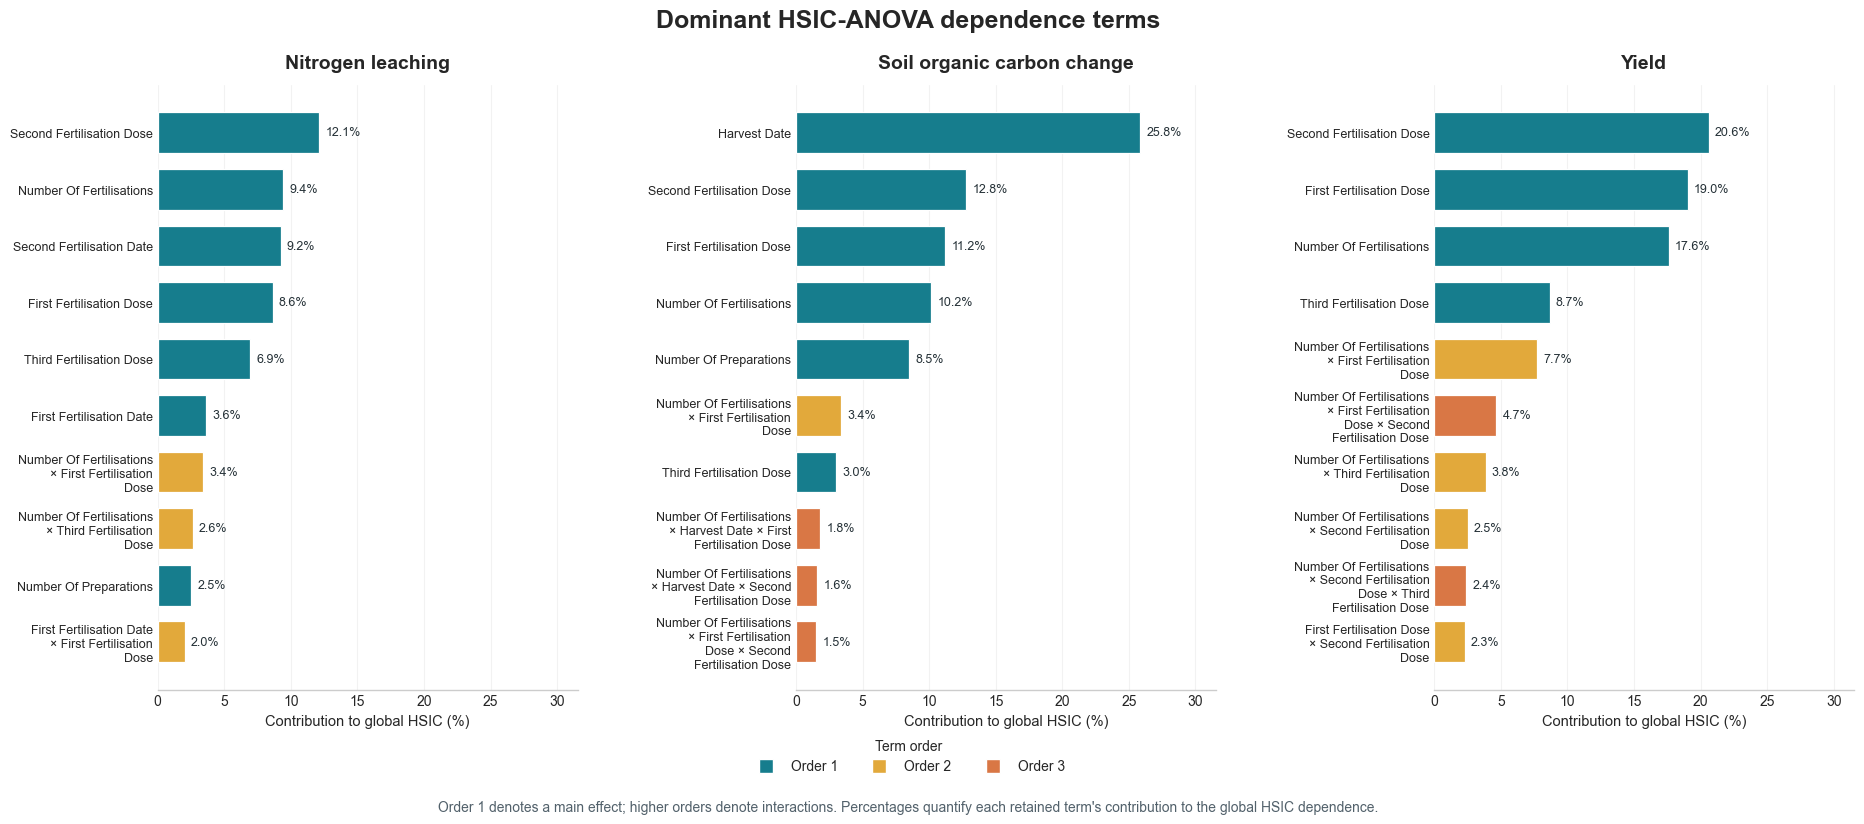

Figure saved to: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_all_outputs.png
Table saved to: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_all_outputs.csv


,output_label,order,term_label,global_var_pct
9,Nitrogen leaching,1,Second Fertilisation Dose,12.14
8,Nitrogen leaching,1,Number Of Fertilisations,9.42
7,Nitrogen leaching,1,Second Fertilisation Date,9.22
6,Nitrogen leaching,1,First Fertilisation Dose,8.62
5,Nitrogen leaching,1,Third Fertilisation Dose,6.92
4,Nitrogen leaching,1,First Fertilisation Date,3.65
3,Nitrogen leaching,2,Number Of Fertilisations × First Fertilisation...,3.43
2,Nitrogen leaching,2,Number Of Fertilisations × Third Fertilisation...,2.63
1,Nitrogen leaching,1,Number Of Preparations,2.49
0,Nitrogen leaching,2,First Fertilisation Date × First Fertilisation...,2.03


In [9]:
# =============================================================================
# HSIC-ANOVA: dominant dependence terms for all MAELIA outputs
# =============================================================================

import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

HSIC_TERMS_CSV = OUTPUT_DIR / "hsic_anova_terms_real_maelia.csv"
FIG_DIR = OUTPUT_DIR / "hsic_anova_decomposition"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "hsic_all" in globals() and not hsic_all.empty:
    hsic_terms = hsic_all.copy()
else:
    hsic_terms = pd.read_csv(HSIC_TERMS_CSV)

if hsic_terms.empty:
    raise ValueError("No HSIC-ANOVA terms are available. Run the HSIC computation first.")

if "global_var_pct" not in hsic_terms.columns and "contribution_hsic_globale_pct" in hsic_terms.columns:
    hsic_terms = hsic_terms.rename(
        columns={"contribution_hsic_globale_pct": "global_var_pct"}
    )
if "variables" not in hsic_terms.columns and "name" in hsic_terms.columns:
    hsic_terms["variables"] = hsic_terms["name"]

required_cols = {"sortie", "order", "variables", "global_var_pct"}
missing = required_cols - set(hsic_terms.columns)
if missing:
    raise ValueError(f"Missing HSIC columns: {sorted(missing)}")

outputs = [name for name in OUTPUT_COLS if name in set(hsic_terms["sortie"])]
if not outputs:
    outputs = list(hsic_terms["sortie"].dropna().unique())

TOP_N = 10
ORDER_COLORS = {
    1: "#167D8D",
    2: "#E2A93B",
    3: "#D97745",
    4: "#B94A48",
}

def display_feature_name(raw_name):
    return FEATURE_DISPLAY_NAMES.get(raw_name, raw_name).replace("_", " ")

def format_hsic_term(term, width=25):
    names = [display_feature_name(item.strip()) for item in str(term).split("&")]
    return textwrap.fill(" × ".join(names), width=width, break_long_words=False)

plot_tables = {}
for output in outputs:
    data = (
        hsic_terms.loc[hsic_terms["sortie"] == output]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["global_var_pct"])
        .sort_values("global_var_pct", ascending=False)
        .head(TOP_N)
        .copy()
    )
    if data.empty:
        continue
    data["order"] = data["order"].astype(int)
    data["display_term"] = data["variables"].map(format_hsic_term)
    plot_tables[output] = data.sort_values("global_var_pct", ascending=True)

if not plot_tables:
    raise ValueError("No finite HSIC contribution could be plotted.")

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(
    1,
    len(plot_tables),
    figsize=(19.5, 8.4),
    squeeze=False,
)
axes = axes.ravel()

global_max = max(
    float(data["global_var_pct"].max())
    for data in plot_tables.values()
)
xmax = max(1.0, global_max * 1.22)

for ax, (output, data) in zip(axes, plot_tables.items()):
    colors = data["order"].map(lambda order: ORDER_COLORS.get(order, "#66788A"))
    bars = ax.barh(
        data["display_term"],
        data["global_var_pct"],
        color=colors,
        edgecolor="white",
        linewidth=0.9,
        height=0.72,
    )

    ax.set_xlim(0, xmax)
    ax.set_title(
        OUTPUT_DISPLAY_NAMES.get(output, output),
        fontsize=14,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Contribution to global HSIC (%)", fontsize=10.5)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", alpha=0.24)
    ax.grid(axis="y", visible=False)

    for bar, value in zip(bars, data["global_var_pct"]):
        ax.text(
            min(value + xmax * 0.015, xmax * 0.97),
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            ha="left",
            fontsize=9,
            color="#263238",
        )

    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)

present_orders = sorted(
    {
        int(order)
        for data in plot_tables.values()
        for order in data["order"].unique()
    }
)
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        markersize=10,
        markerfacecolor=ORDER_COLORS.get(order, "#66788A"),
        markeredgecolor="white",
        label=f"Order {order}",
    )
    for order in present_orders
]

fig.suptitle(
    "Dominant HSIC-ANOVA dependence terms",
    fontsize=18,
    fontweight="bold",
    y=0.97,
)
fig.legend(
    handles=legend_handles,
    title="Term order",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.045),
    ncol=max(1, len(legend_handles)),
    frameon=False,
)
fig.text(
    0.5,
    0.012,
    "Order 1 denotes a main effect; higher orders denote interactions. "
    "Percentages quantify each retained term's contribution to the global HSIC dependence.",
    ha="center",
    va="bottom",
    fontsize=10,
    color="#52616B",
)
fig.subplots_adjust(left=0.115, right=0.985, top=0.88, bottom=0.16, wspace=0.52)

fig_path = FIG_DIR / "hsic_anova_top_terms_all_outputs.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

combined_top_terms = pd.concat(
    [
        data.assign(
            output_label=OUTPUT_DISPLAY_NAMES.get(output, output),
            term_label=data["variables"].map(
                lambda value: " × ".join(
                    display_feature_name(item.strip())
                    for item in str(value).split("&")
                )
            ),
        )
        for output, data in plot_tables.items()
    ],
    ignore_index=True,
)
table_path = FIG_DIR / "hsic_anova_top_terms_all_outputs.csv"
combined_top_terms.to_csv(table_path, index=False)

print(f"Figure saved to: {fig_path}")
print(f"Table saved to: {table_path}")
display(
    combined_top_terms[
        ["output_label", "order", "term_label", "global_var_pct"]
    ]
    .sort_values(["output_label", "global_var_pct"], ascending=[True, False])
    .round({"global_var_pct": 2})
)


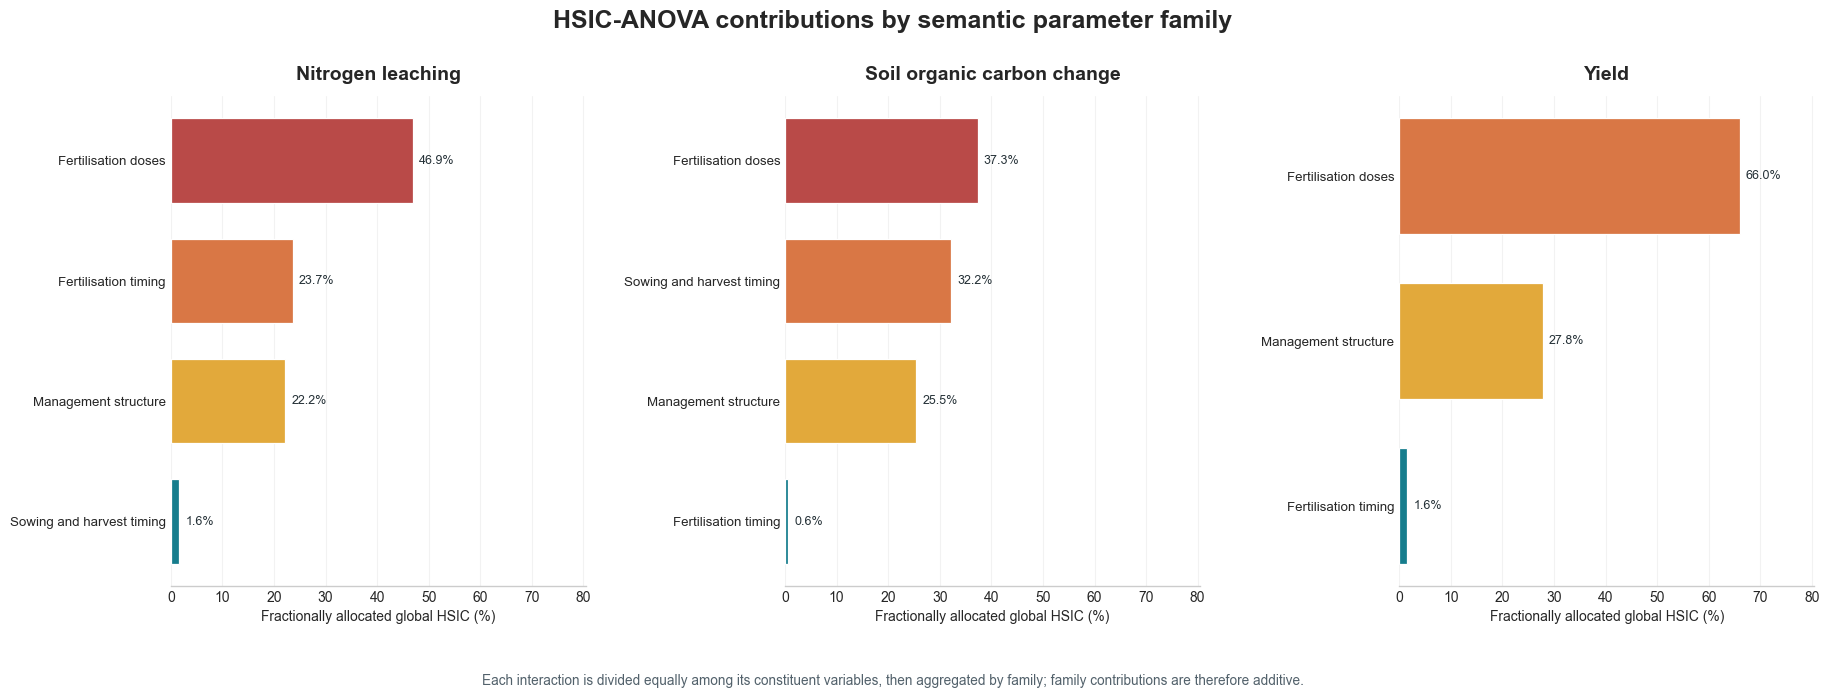

Figure saved to: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_semantic_groups/hsic_anova_semantic_families.png


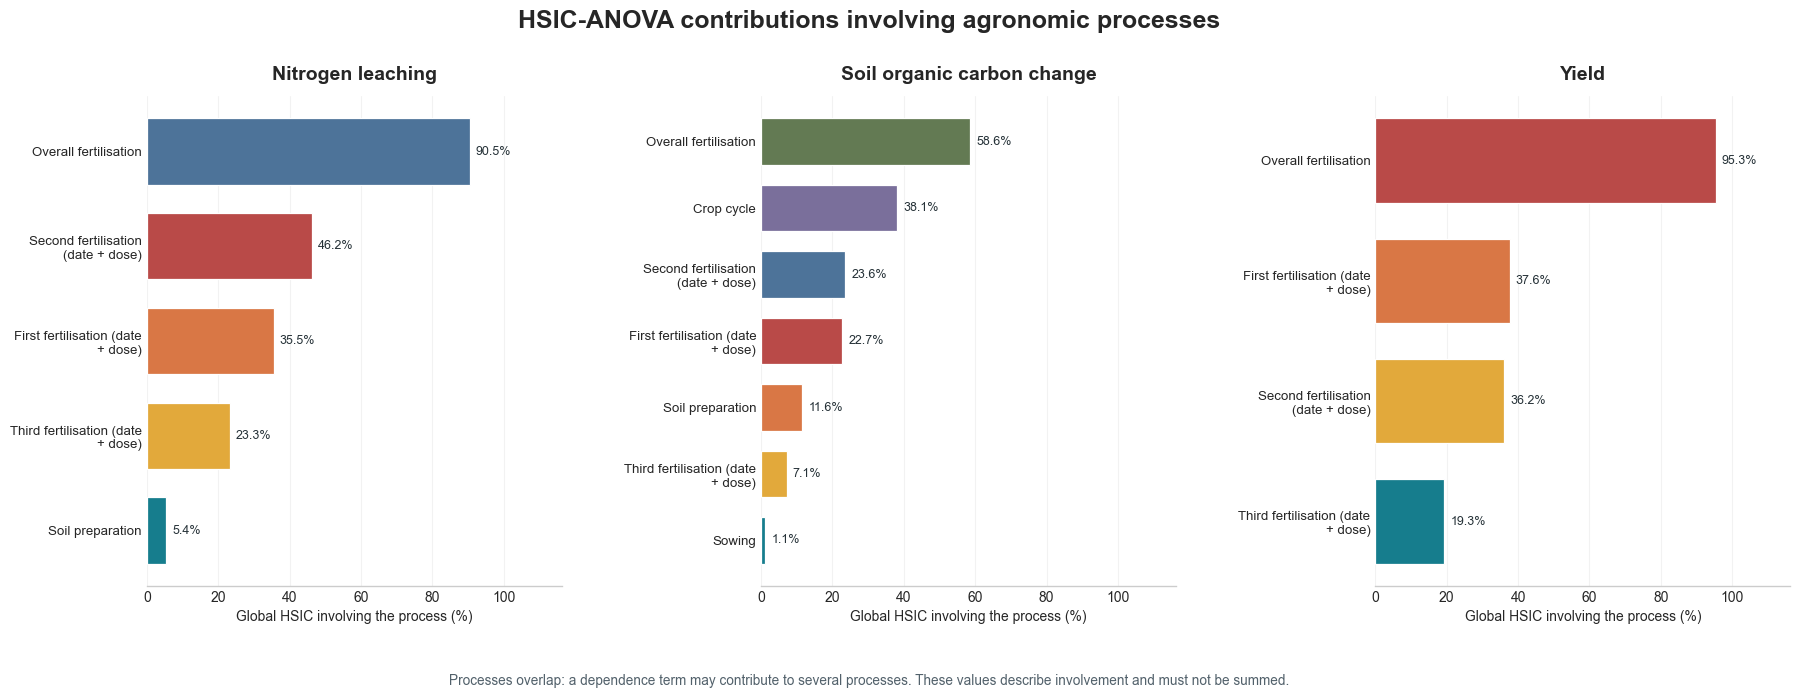

Figure saved to: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_semantic_groups/hsic_anova_agronomic_processes.png
Tables saved in: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_semantic_groups


,output,semantic_family,hsic_contribution_pct
0,N_lixi,Fertilisation doses,46.91
1,N_lixi,Fertilisation timing,23.65
2,N_lixi,Management structure,22.21
3,N_lixi,Sowing and harvest timing,1.63
4,dCorg,Fertilisation doses,37.34
7,dCorg,Sowing and harvest timing,32.16
6,dCorg,Management structure,25.47
5,dCorg,Fertilisation timing,0.65
8,rdt,Fertilisation doses,65.96
10,rdt,Management structure,27.79


,output,agronomic_process,hsic_contribution_pct
1,N_lixi,Overall fertilisation,90.47
2,N_lixi,Second fertilisation (date + dose),46.25
0,N_lixi,First fertilisation (date + dose),35.54
4,N_lixi,Third fertilisation (date + dose),23.27
3,N_lixi,Soil preparation,5.36
7,dCorg,Overall fertilisation,58.57
5,dCorg,Crop cycle,38.07
8,dCorg,Second fertilisation (date + dose),23.60
6,dCorg,First fertilisation (date + dose),22.73
9,dCorg,Soil preparation,11.56


In [10]:
# =============================================================================
# HSIC-ANOVA aggregation by semantic families and agronomic processes
# =============================================================================

import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HSIC_TERMS_CSV = OUTPUT_DIR / "hsic_anova_terms_real_maelia.csv"
GROUP_DIR = OUTPUT_DIR / "hsic_anova_semantic_groups"
GROUP_DIR.mkdir(parents=True, exist_ok=True)

if "hsic_all" in globals() and not hsic_all.empty:
    hsic_terms = hsic_all.copy()
else:
    hsic_terms = pd.read_csv(HSIC_TERMS_CSV)

if hsic_terms.empty:
    raise ValueError("No HSIC-ANOVA terms are available. Run the HSIC computation first.")

hsic_terms["global_var_pct"] = pd.to_numeric(
    hsic_terms["global_var_pct"], errors="coerce"
).fillna(0.0)

def parse_hsic_variables(value):
    text = str(value)
    found = []
    for feature in AGRI_FEATURES:
        pattern = rf"(?<![A-Za-z0-9_]){re.escape(feature)}(?![A-Za-z0-9_])"
        if re.search(pattern, text):
            found.append(feature)
    return found

hsic_terms["variable_list"] = hsic_terms["variables"].apply(parse_hsic_variables)
hsic_terms = hsic_terms[hsic_terms["variable_list"].map(len) > 0].copy()

# Additive semantic families: each HSIC term is divided equally among its
# constituent variables before aggregation, which prevents double counting.
SEMANTIC_GROUPS = {
    "Management structure": {
        "n_ferti", "nb_prepa",
    },
    "Sowing and harvest timing": {
        "Date_Semis", "Date_Recolte", "Delta_PREPA_Semis",
    },
    "Fertilisation timing": {
        "Date_F1", "Date_F2", "Date_F3",
    },
    "Fertilisation doses": {
        "Dose_F1", "Dose_F2", "Dose_F3",
    },
    "Operation depths": {
        "Profondeur_Semis", "Profondeur_Prepa_1", "Profondeur_Prepa_2",
    },
}

variable_to_semantic_group = {
    variable: group
    for group, variables in SEMANTIC_GROUPS.items()
    for variable in variables
}

semantic_rows = []
for _, row in hsic_terms.iterrows():
    variables = row["variable_list"]
    if not variables:
        continue
    share_per_variable = row["global_var_pct"] / len(variables)
    for variable in variables:
        semantic_rows.append({
            "output": row["sortie"],
            "semantic_family": variable_to_semantic_group.get(variable, "Other"),
            "variable": variable,
            "hsic_contribution_pct": share_per_variable,
        })

semantic_df = pd.DataFrame(semantic_rows)
semantic_summary = (
    semantic_df
    .groupby(["output", "semantic_family"], as_index=False)["hsic_contribution_pct"]
    .sum()
    .sort_values(["output", "hsic_contribution_pct"], ascending=[True, False])
)
semantic_summary.to_csv(
    GROUP_DIR / "hsic_anova_semantic_families.csv",
    index=False,
)

# Overlapping agronomic processes answer process-level questions. Because one
# HSIC term may involve several processes, these contributions are non-additive.
AGRONOMIC_PROCESSES = {
    "Soil preparation": {
        "nb_prepa", "Delta_PREPA_Semis",
        "Profondeur_Prepa_1", "Profondeur_Prepa_2",
    },
    "Sowing": {
        "Date_Semis", "Profondeur_Semis",
    },
    "Crop cycle": {
        "Date_Semis", "Date_Recolte",
    },
    "Overall fertilisation": {
        "n_ferti", "Date_F1", "Date_F2", "Date_F3",
        "Dose_F1", "Dose_F2", "Dose_F3",
    },
    "First fertilisation (date + dose)": {
        "Date_F1", "Dose_F1",
    },
    "Second fertilisation (date + dose)": {
        "Date_F2", "Dose_F2",
    },
    "Third fertilisation (date + dose)": {
        "Date_F3", "Dose_F3",
    },
}

process_rows = []
for _, row in hsic_terms.iterrows():
    variables = set(row["variable_list"])
    for process_name, process_variables in AGRONOMIC_PROCESSES.items():
        overlap = variables.intersection(process_variables)
        if overlap:
            process_rows.append({
                "output": row["sortie"],
                "agronomic_process": process_name,
                "involved_variables": ", ".join(sorted(overlap)),
                "hsic_term": row["variables"],
                "hsic_contribution_pct": row["global_var_pct"],
            })

process_df = pd.DataFrame(process_rows)
process_summary = (
    process_df
    .groupby(["output", "agronomic_process"], as_index=False)["hsic_contribution_pct"]
    .sum()
    .sort_values(["output", "hsic_contribution_pct"], ascending=[True, False])
)
process_summary.to_csv(
    GROUP_DIR / "hsic_anova_agronomic_processes.csv",
    index=False,
)

plt.style.use("seaborn-v0_8-whitegrid")
PANEL_COLORS = ["#167D8D", "#E2A93B", "#D97745", "#B94A48", "#4D7399", "#7A6F9B", "#637A53"]

def wrapped_label(value, width=25):
    return textwrap.fill(str(value), width=width, break_long_words=False)

def plot_group_summary(summary, group_col, value_col, title, fig_name, xlabel, note):
    outputs = [name for name in OUTPUT_COLS if name in set(summary["output"])]
    if not outputs:
        outputs = list(summary["output"].dropna().unique())

    datasets = {
        output: (
            summary.loc[summary["output"] == output]
            .sort_values(value_col, ascending=True)
            .tail(10)
            .copy()
        )
        for output in outputs
    }
    global_max = max(
        float(data[value_col].max())
        for data in datasets.values()
        if not data.empty
    )
    xmax = max(1.0, global_max * 1.22)

    fig, axes = plt.subplots(
        1,
        len(outputs),
        figsize=(19.0, 7.2),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, output in zip(axes, outputs):
        data = datasets[output]
        labels = data[group_col].map(wrapped_label)
        colors = PANEL_COLORS[:len(data)]
        bars = ax.barh(
            labels,
            data[value_col],
            color=colors,
            edgecolor="white",
            linewidth=0.9,
            height=0.7,
        )

        ax.set_xlim(0, xmax)
        ax.set_title(
            OUTPUT_DISPLAY_NAMES.get(output, output),
            fontsize=14,
            fontweight="bold",
            pad=12,
        )
        ax.set_xlabel(xlabel, fontsize=10)
        ax.tick_params(axis="y", labelsize=9.5)
        ax.grid(axis="x", alpha=0.24)
        ax.grid(axis="y", visible=False)

        for bar, value in zip(bars, data[value_col]):
            ax.text(
                min(value + xmax * 0.015, xmax * 0.97),
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%",
                va="center",
                ha="left",
                fontsize=9,
                color="#263238",
            )

        for spine in ("top", "right", "left"):
            ax.spines[spine].set_visible(False)

    fig.suptitle(title, fontsize=18, fontweight="bold", y=0.96)
    fig.text(
        0.5,
        0.018,
        note,
        ha="center",
        va="bottom",
        fontsize=9.8,
        color="#52616B",
    )
    fig.subplots_adjust(left=0.12, right=0.985, top=0.84, bottom=0.16, wspace=0.48)

    fig_path = GROUP_DIR / fig_name
    fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Figure saved to: {fig_path}")

plot_group_summary(
    semantic_summary,
    group_col="semantic_family",
    value_col="hsic_contribution_pct",
    title="HSIC-ANOVA contributions by semantic parameter family",
    fig_name="hsic_anova_semantic_families.png",
    xlabel="Fractionally allocated global HSIC (%)",
    note=(
        "Each interaction is divided equally among its constituent variables, "
        "then aggregated by family; family contributions are therefore additive."
    ),
)

plot_group_summary(
    process_summary,
    group_col="agronomic_process",
    value_col="hsic_contribution_pct",
    title="HSIC-ANOVA contributions involving agronomic processes",
    fig_name="hsic_anova_agronomic_processes.png",
    xlabel="Global HSIC involving the process (%)",
    note=(
        "Processes overlap: a dependence term may contribute to several processes. "
        "These values describe involvement and must not be summed."
    ),
)

print(f"Tables saved in: {GROUP_DIR}")
display(semantic_summary.round(2))
display(process_summary.round(2))
